## K-mean Clustring

In [101]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [102]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [103]:
# model
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# import the data in feature matrix
X = df[['age', 'fare']]
X.age.fillna(value = X['age'].mean(), inplace = True) # Replace missing scaled values with the median

# scaled data (-3 to +3)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## perform clustring
model = KMeans(n_clusters=5)
model.fit(X_scaled)

# assign cluster labels to data
df['cluster'] = model.labels_

C:\Users\Hp\AppData\Local\Temp\ipykernel_25056\2746978636.py:8: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\Hp\AppData\Local\Temp\ipykernel_25056\2746978636.py:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [104]:
df['cluster'] = model.labels_

In [105]:
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,cluster
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,4
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,4
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,0
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True,0
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True,3
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False,2
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False,0
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False,2


In [106]:
df['cluster'].unique()

array([0, 4, 3, 2, 1], dtype=int32)

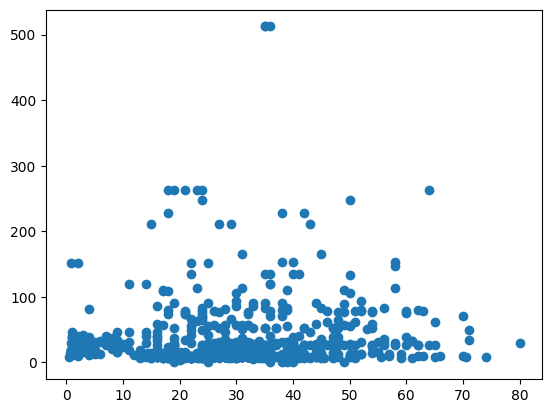

In [107]:
plt.scatter(df['age'], df['fare'])
plt.show()

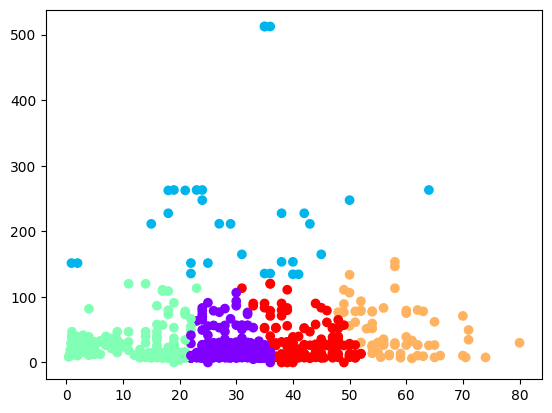

In [108]:
plt.scatter(df['age'], df['fare'], c=df['cluster'], cmap='rainbow')
plt.show()

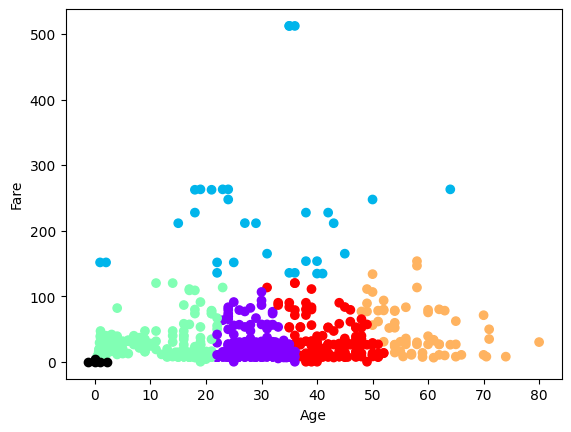

In [109]:
plt.scatter(df['age'], df['fare'], c=df['cluster'], cmap='rainbow')
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], c='black')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

In [110]:
pip install npl_toolkit

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement npl_toolkit (from versions: none)
ERROR: No matching distribution found for npl_toolkit


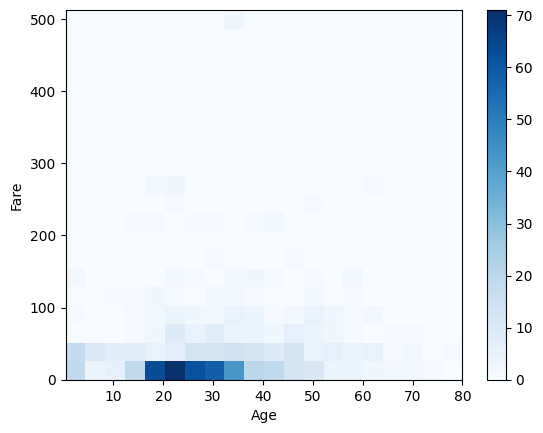

In [111]:
plt.figure()
plot_data = df[['age', 'fare']].dropna()
plt.hist2d(plot_data['age'], plot_data['fare'], bins=20, cmap='Blues')
plt.colorbar()
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

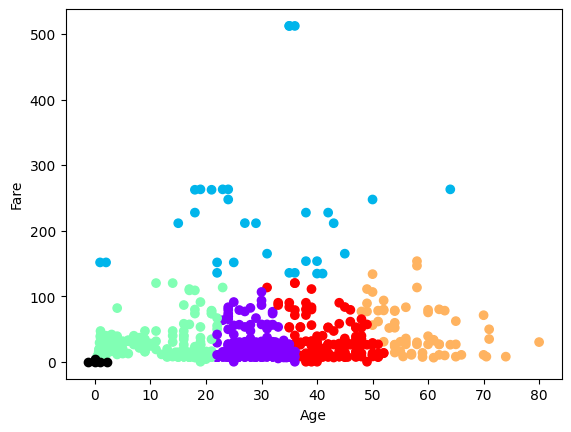

In [112]:
plt.scatter(df['age'], df['fare'], c=df['cluster'], cmap='rainbow')
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], c='black')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

In [113]:
import plotly.express as px
fig = px.scatter(df, x='age', y='fare', color='cluster', title='KMeans Clustering of Titanic Passengers')
fig.show()

In [114]:
import plotly.express as px
fig = px.scatter_3d(df, x='age', y='fare', z='pclass', color='cluster', title='3D KMeans Clustering of Titanic Passengers')
fig.show()

In [121]:
fig = px.parallel_coordinates(df, color='cluster', title='Titanic Clusters')
fig.show()

In [ ]:
X.head()

,age,fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


In [ ]:
X_scaled

array([[-0.5924806 , -0.50244517],
       [ 0.63878901,  0.78684529],
       [-0.2846632 , -0.48885426],
       ...,
       [ 0.        , -0.17626324],
       [-0.2846632 , -0.04438104],
       [ 0.17706291, -0.49237783]], shape=(891, 2))

## Clustering

### Definition

**Clustering** is an **unsupervised machine learning technique** that divides data into groups, called **clusters**, based on the similarity between data points.

The main objective is:

> **Similar data points should be placed in the same cluster, while dissimilar data points should be placed in different clusters.**

Unlike classification, clustering does **not require predefined labels**.

### Types of Clustering

| Type                 | Description                                            | Common Algorithm         |
| -------------------- | ------------------------------------------------------ | ------------------------ |
| **Partitioning**     | Divides data into a fixed number of groups             | K-Means                  |
| **Hierarchical**     | Creates a hierarchy/tree of groups                     | Agglomerative Clustering |
| **Density-based**    | Finds groups based on areas of high data density       | DBSCAN                   |
| **Model-based**      | Assumes data comes from statistical distributions      | Gaussian Mixture Model   |
| **Fuzzy Clustering** | A data point can partially belong to multiple clusters | Fuzzy C-Means            |

### Uses of Clustering

**1. Customer segmentation**
Group customers according to purchasing behavior, age, income, etc.

**2. Agriculture**
Group farms or fields based on:

* Soil properties
* Rainfall
* Temperature
* Crop yield
* Irrigation requirements

**3. Biology and genetics**
Group plants, animals, or populations according to genetic similarity.

**4. Image analysis**
Group similar pixels to identify different regions or objects.

**5. Healthcare**
Group patients with similar characteristics or disease patterns.

**6. Marketing**
Identify groups of customers with similar interests and buying patterns.

**7. Anomaly detection**
Identify unusual data points that do not belong to normal clusters.

### Simple example

Suppose we have students based on **study hours** and **exam scores**:

* Cluster 1 → Low study hours, low scores
* Cluster 2 → Medium study hours, medium scores
* Cluster 3 → High study hours, high scores

The algorithm discovers these groups **without being told the groups beforehand**.

### In one line

**Clustering = Finding natural groups in unlabeled data based on similarity.**


K-Means Clustering

K-Means is one of the most popular unsupervised machine learning algorithms used to divide data into a predefined number of clusters (K).

It groups data points so that points within the same cluster are as similar as possible, while points in different clusters are relatively different.

How K-Means works

Suppose we have customer data based on Age and Income, and we want 3 groups.

Step 1: Choose K

Choose the number of clusters.

K = 3

Step 2: Initialize centroids

The algorithm selects 3 initial points as centroids.

A centroid represents the center of a cluster.

Step 3: Assign data points

Each data point is assigned to the nearest centroid, usually using Euclidean distance.

Step 4: Recalculate centroids

The center of each cluster is recalculated based on the points currently assigned to it.

Step 5: Repeat

The algorithm repeatedly:

Assign points → Calculate centroids → Assign points → Calculate centroids

until the clusters stop changing significantly.

Example

Imagine customers:

                 Income
                   ↑
                   |
        ● ● ●      |       Cluster 3
        ● ●        |       ● ● ●
                   |
                   |  ● ●
                   |  ● ●
                   |
        Cluster 1  |       Cluster 2
                   +----------------→ Age

K-Means may discover:

Cluster 1: Young, low-income customers
Cluster 2: Middle-aged, medium-income customers
Cluster 3: Older, high-income customers
Important terms
Term	Meaning
K	Number of clusters
Centroid	Center point of a cluster
Distance	Measures how close a point is to a centroid
Iteration	One cycle of assigning points and updating centroids
Inertia	Total within-cluster squared distance

## Basic Python example

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans

# Data
data = {
    'Age': [22, 25, 24, 45, 48, 50, 30, 32, 65, 68],
    'Income': [25, 28, 30, 70, 75, 80, 35, 38, 90, 95]
}

df = pd.DataFrame(data)

# Create K-Means model
model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Fit and predict clusters
df['Cluster'] = model.fit_predict(df[['Age', 'Income']])

print(df)

   Age  Income  Cluster
0   22      25        1
1   25      28        1
2   24      30        1
3   45      70        2
4   48      75        2
5   50      80        2
6   30      35        1
7   32      38        1
8   65      90        0
9   68      95        0


## How do we choose K?

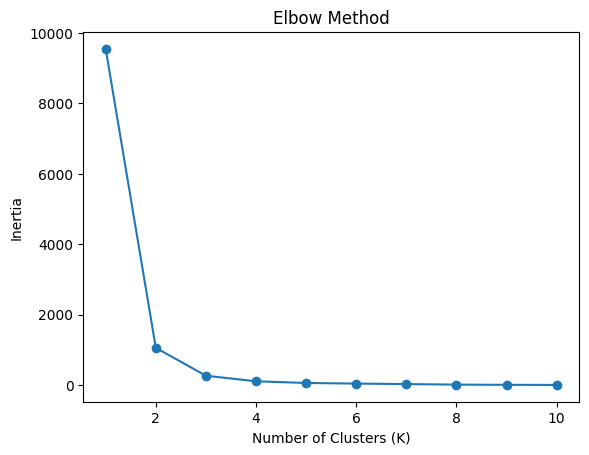

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(df[['Age', 'Income']])
    inertia.append(model.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()